<a href="https://colab.research.google.com/github/SinhaPushkar047/Deep_Learning_Projects/blob/main/Transfer_Learning_Feature_Extraction_Without_Data_Aug.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [84]:
# Install/update Kaggle
!pip install -q --upgrade kaggle

# Setup Kaggle API
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d puneet6060/intel-image-classification --force

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:07<00:00, 50.5MB/s]



In [85]:
# Extract dataset
import zipfile
import os

zip_path = "/content/intel-image-classification.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content")

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [86]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten,Dropout,BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications.vgg16 import VGG16

In [87]:
train_ds=keras.utils.image_dataset_from_directory(
    directory='/content/seg_train/seg_train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)
validation_ds=keras.utils.image_dataset_from_directory(
    directory='/content/seg_test/seg_test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)


Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.


In [88]:
conv_base=VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(256,256,3)
)

In [89]:
model=Sequential([
    conv_base,
    Flatten(),
    Dense(150,activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(75,activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(30,activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(6,activation='softmax'),
])

In [90]:
conv_base.trainable=False

In [91]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 8, 8, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 150)            │     4,915,350 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 150)            │           600 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 75)             │        11,325 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 75)             │           300 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 75)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 30)             │         2,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 30)             │           120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 6)              │           186 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,644,849 (74.94 MB)

 Trainable params: 4,929,651 (18.81 MB)

 Non-trainable params: 14,715,198 (56.13 MB)

In [92]:
def process(image,label):
  image=tf.cast(image/255,tf.float32)
  return image,label
train_ds=train_ds.map(process)
validation_ds=validation_ds.map(process)

In [93]:
model.compile(optimizer='adam',metrics=['accuracy'],loss='sparse_categorical_crossentropy')

In [94]:
callback=EarlyStopping(
    monitor='val_loss',
    verbose=1,
    mode='min',
    min_delta=0.01,
    patience=5,
    restore_best_weights=True
)

In [95]:
history=model.fit(train_ds,verbose=1,validation_data=validation_ds,epochs=100,callbacks=callback,batch_size=32)

Epoch 1/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 156s 329ms/step - accuracy: 0.7965 - loss: 0.5869 - val_accuracy: 0.8680 - val_loss: 0.3846
Epoch 2/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 155s 353ms/step - accuracy: 0.8824 - loss: 0.3474 - val_accuracy: 0.8593 - val_loss: 0.4014
Epoch 3/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 139s 316ms/step - accuracy: 0.9053 - loss: 0.2742 - val_accuracy: 0.8843 - val_loss: 0.3552
Epoch 4/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 138s 314ms/step - accuracy: 0.9240 - loss: 0.2246 - val_accuracy: 0.8313 - val_loss: 0.5443
Epoch 5/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 138s 315ms/step - accuracy: 0.9334 - loss: 0.2018 - val_accuracy: 0.8790 - val_loss: 0.3880
Epoch 6/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 139s 316ms/step - accuracy: 0.9448 - loss: 0.1613 - val_accuracy: 0.8607 - val_loss: 0.5002
Epoch 7/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 139s 316ms/step - accuracy: 0.9483 - loss: 0.1556 - val_accuracy: 0.8137 - val_loss: 0.7016
Epoch 8/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 138s 315ms/step - accuracy: 

In [96]:
import matplotlib.pyplot as plt

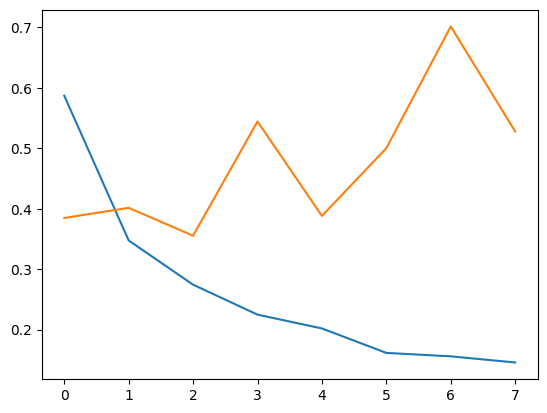

In [97]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')

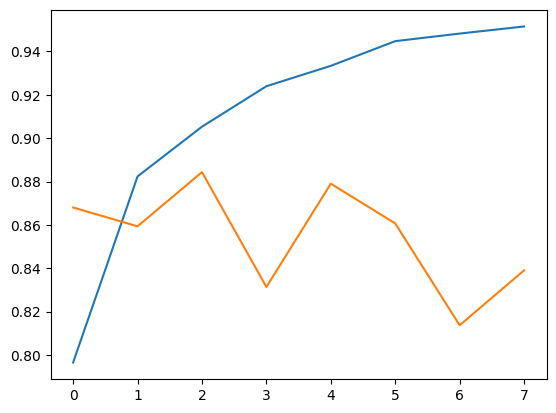

In [98]:
plt.plot(history.history['accuracy'],label='accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')